In [378]:
!pip install pandas numpy scikit-learn imbalanced-learn matplotlib seaborn --quiet

In [379]:
import json
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import os

from collections import Counter
from sqlalchemy import create_engine
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, confusion_matrix, classification_report
)

warnings.filterwarnings('ignore')
np.random.seed(42)

print("Semua library berhasil diimport.")

Semua library berhasil diimport.


In [380]:
# koneksi ke database mysql
DB_HOST     = os.getenv('DB_HOST', 'localhost')
DB_PORT     = int(os.getenv('DB_PORT', '3306'))
DB_USER     = os.getenv('DB_USER', 'root')
DB_PASSWORD = os.getenv('DB_PASSWORD', '')
DB_NAME     = os.getenv('DB_NAME', 'datawarehouse_om')

# engine koneksi (SQLAlchemy)
engine = create_engine(
    f"mysql+pymysql://{DB_USER}:{DB_PASSWORD}@{DB_HOST}:{DB_PORT}/{DB_NAME}"
)
print(f"Koneksi ke database siap: {DB_HOST}:{DB_PORT}/{DB_NAME}")

Koneksi ke database siap: localhost:3306/datawarehouse_om


In [381]:
query = """
    SELECT
        f.fact_id,
        f.severity,
        t.month,
        m.scope_of_work,
        s.city
    FROM fact_maintenance_activity f
    JOIN dim_time             t  ON f.time_id        = t.time_id
    JOIN dim_maintenance_type m  ON f.maintenance_id = m.maintenance_id
    JOIN dim_site             s  ON f.site_id        = s.site_id
        AND s.is_current = 1
"""
df = pd.read_sql(query, con=engine)
print(f"Data berhasil diambil: {df.shape[0]:,} baris × {df.shape[1]} kolom")
print(df.head(3))

Data berhasil diambil: 52,427 baris × 5 kolom
   fact_id severity  month scope_of_work                 city
0     1421    minor      1            q2  kabupaten bondowoso
1     5963    minor      2            b4  kabupaten bondowoso
2     9883    minor      3           vw2  kabupaten bondowoso


In [382]:
# DATA PREPARATION
NUM_COLS = ['month']

for col in NUM_COLS:
    df[col] = pd.to_numeric(df[col], errors='coerce')

print("Tipe data setelah konversi:")
print(df.dtypes)
print(f"\nNilai null per kolom:")
print(df.isnull().sum())

Tipe data setelah konversi:
fact_id           int64
severity         object
month             int64
scope_of_work    object
city             object
dtype: object

Nilai null per kolom:
fact_id          0
severity         0
month            0
scope_of_work    0
city             0
dtype: int64


In [383]:
# definisi fitur
FEATURE_COLS = ['month', 'scope_of_work', 'city']
TARGET_COL = 'severity'
CAT_COLS = ['scope_of_work', 'city']

label_encoders = {}
for col in CAT_COLS:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col].astype(str).str.strip().str.lower())
    label_encoders[col] = le
    print(f"Encoded '{col}' → {len(le.classes_)} kelas unik")

Encoded 'scope_of_work' → 52 kelas unik
Encoded 'city' → 31 kelas unik


In [384]:
# Encode target: minor = 0, major = 1
df['severity_encoded'] = df[TARGET_COL].str.strip().str.lower().map({'minor': 0, 'major': 1})

X = df[FEATURE_COLS].copy()
y = df['severity_encoded'].copy()

print(f"\nFitur  (X) : {X.shape}")
print(f"Target (y) : {y.shape} →  0 = minor, 1 = major")


Fitur  (X) : (52427, 3)
Target (y) : (52427,) →  0 = minor, 1 = major


In [385]:
# split data 80:20
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size   = 0.2,
    random_state= 42,
    stratify    = y
)

print("HASIL SPLIT DATA")
print(f"  Training (80%): {len(X_train):>6} baris")
print(f"  Testing  (20%): {len(X_test):>6} baris")
print(f"  Total data    : {len(X):>6} baris")
print(f"\nDistribusi Training :")
for label, count in sorted(Counter(y_train).items()):
    name = 'major' if label == 1 else 'minor'
    print(f"  {name}: {count}")

HASIL SPLIT DATA
  Training (80%):  41941 baris
  Testing  (20%):  10486 baris
  Total data    :  52427 baris

Distribusi Training :
  minor: 34236
  major: 7705


In [386]:
# CLASS WEIGHT
# Hitung class weight otomatis
class_counts = Counter(y_train)
class_weights = {
    0: len(y_train) / (2 * class_counts[0]),  # minor
    1: len(y_train) / (2 * class_counts[1])   # major
}

print(f"Class Weights:")
print(f"  Class 0 (minor): {class_weights[0]:.4f}")
print(f"  Class 1 (major): {class_weights[1]:.4f}")
print(f"  Ratio: {class_weights[1] / class_weights[0]:.2f}x")

print(f"\nKeterangan:")
print(f"  1) class_weight='balanced' otomatis menghitung bobot seperti di atas")
print(f"  2) Error pada kelas minoritas (major) akan dipenalti lebih tinggi")
print(f"  3) TIDAK ada resampling → TIDAK ada data leakage")

Class Weights:
  Class 0 (minor): 0.6125
  Class 1 (major): 2.7217
  Ratio: 4.44x

Keterangan:
  1) class_weight='balanced' otomatis menghitung bobot seperti di atas
  2) Error pada kelas minoritas (major) akan dipenalti lebih tinggi
  3) TIDAK ada resampling → TIDAK ada data leakage


In [387]:
# distribusi kelas target
sev_counts = df['severity'].value_counts()
total      = len(df)

print("DISTRIBUSI TARGET (SEVERITY)")
for label, count in sev_counts.items():
    pct = count / total * 100
    bar = "█" * int(pct / 2)
    print(f"  {label:<8}: {count:>6} ({pct:5.1f}%)  {bar}")

ratio = sev_counts['minor'] / sev_counts['major']
print(f"\nImbalance Ratio (minor:major) = {ratio:.2f}:1")
print(f"Data tidak seimbang")

DISTRIBUSI TARGET (SEVERITY)
  minor   :  42796 ( 81.6%)  ████████████████████████████████████████
  major   :   9631 ( 18.4%)  █████████

Imbalance Ratio (minor:major) = 4.44:1
Data tidak seimbang


In [388]:
# CROSS VALIDATION (K-FOLD)
cv_pipeline = RandomForestClassifier(
    n_estimators=100,
    max_depth=15,
    min_samples_split=5,
    min_samples_leaf=2,
    class_weight='balanced',  # COST-SENSITIVE LEARNING
    random_state=42,
    n_jobs=-1
)

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

cv_results = cross_validate(
    cv_pipeline, X_train, y_train, 
    cv      = skf,
    scoring = ['accuracy', 'precision_weighted', 'recall_weighted', 'f1_weighted'],
    n_jobs  = -1,
    return_train_score=True
)

print("HASIL CROSS-VALIDATION (5-Fold, Weighted Avg)")
metrics_cv = {
    'Accuracy' : cv_results['test_accuracy'],
    'Precision': cv_results['test_precision_weighted'],
    'Recall'   : cv_results['test_recall_weighted'],
    'F1-Score' : cv_results['test_f1_weighted'],
}
print(f"  {'Metrik':<12} {'Fold 1':>8} {'Fold 2':>8} {'Fold 3':>8} {'Fold 4':>8} {'Fold 5':>8}   {'Mean':>8}")
print(f"  {'-'*70}")
for metric, vals in metrics_cv.items():
    fold_str = '  '.join([f"{v:.4f}" for v in vals])
    print(f"  {metric:<12} {fold_str}   {vals.mean():.4f}  ±{vals.std():.4f}")

print()
print(f"CV selesai, Akurasi rata-rata: {cv_results['test_accuracy'].mean()*100:.2f}% ± {cv_results['test_accuracy'].std()*100:.2f}%")

HASIL CROSS-VALIDATION (5-Fold, Weighted Avg)
  Metrik         Fold 1   Fold 2   Fold 3   Fold 4   Fold 5       Mean
  ----------------------------------------------------------------------
  Accuracy     0.7152  0.6993  0.7123  0.6987  0.6996   0.7050  ±0.0072
  Precision    0.8303  0.8225  0.8293  0.8291  0.8293   0.8281  ±0.0028
  Recall       0.7152  0.6993  0.7123  0.6987  0.6996   0.7050  ±0.0072
  F1-Score     0.7457  0.7320  0.7432  0.7319  0.7326   0.7371  ±0.0061

CV selesai, Akurasi rata-rata: 70.50% ± 0.72%


In [389]:
# MODELING
rf_final = RandomForestClassifier(
    n_estimators=100,
    max_depth=15,
    min_samples_split=5,
    min_samples_leaf=2,
    class_weight='balanced',  # handle imbalance
    random_state=42,
    n_jobs=-1
)

# training
rf_final.fit(X_train, y_train)
print("Model Random Forest berhasil dilatih.")

# testing
y_pred_default = rf_final.predict(X_test)
y_pred_proba = rf_final.predict_proba(X_test)[:, 1]  # Probability kelas 1 (major)

print(f"Prediksi selesai untuk {len(y_test)} data testing.")
print(f"Probability range: [{y_pred_proba.min():.4f}, {y_pred_proba.max():.4f}]")

Model Random Forest berhasil dilatih.
Prediksi selesai untuk 10486 data testing.
Probability range: [0.0000, 0.9994]


In [390]:
# THRESHOLD TUNING
print("THRESHOLD TUNING - Mencari Threshold Optimal")
print(f"{'-'*55}")

thresholds_to_test = [0.5, 0.4, 0.3]
threshold_results = {}

for threshold in thresholds_to_test:
    y_pred_threshold = (y_pred_proba >= threshold).astype(int)
    
    acc  = accuracy_score(y_test, y_pred_threshold)
    prec = precision_score(y_test, y_pred_threshold, average='weighted', zero_division=0)
    rec  = recall_score(y_test, y_pred_threshold, average='weighted', zero_division=0)
    f1   = f1_score(y_test, y_pred_threshold, average='weighted', zero_division=0)
    
    # metrik (fokus pada kelas major/minoritas)
    prec_major = precision_score(y_test, y_pred_threshold, pos_label=1, zero_division=0)
    rec_major  = recall_score(y_test, y_pred_threshold, pos_label=1, zero_division=0)
    f1_major   = f1_score(y_test, y_pred_threshold, pos_label=1, zero_division=0)
    
    threshold_results[threshold] = {
        'y_pred': y_pred_threshold,
        'accuracy': acc,
        'precision': prec,
        'recall': rec,
        'f1': f1,
        'precision_major': prec_major,
        'recall_major': rec_major,
        'f1_major': f1_major,
    }
    
    print(f"Threshold: {threshold:.1f}")
    print(f"  Accuracy (weighted) : {acc*100:6.2f}%")
    print(f"  Precision (weighted): {prec*100:6.2f}%  │ Major: {prec_major*100:6.2f}%")
    print(f"  Recall (weighted)   : {rec*100:6.2f}%  │ Major: {rec_major*100:6.2f}%")
    print(f"  F1-Score (weighted) : {f1*100:6.2f}%  │ Major: {f1_major*100:6.2f}%")
    print()

# Pilih threshold dengan F1-Score tertinggi
best_threshold = max(
    threshold_results.keys(),
    key=lambda t: threshold_results[t]['f1']
)
best_results = threshold_results[best_threshold]
y_pred = best_results['y_pred']

print(f"{'─'*55}")
print(f"                 Threshold Optimal: {best_threshold:.1f}")
print(f"                F1-Score terbaik: {best_results['f1']*100:.2f}%")
print(f"{'─'*55}")

THRESHOLD TUNING - Mencari Threshold Optimal
-------------------------------------------------------
Threshold: 0.5
  Accuracy (weighted) :  70.16%
  Precision (weighted):  83.26%  │ Major:  36.01%
  Recall (weighted)   :  70.16%  │ Major:  80.37%
  F1-Score (weighted) :  73.45%  │ Major:  49.73%

Threshold: 0.4
  Accuracy (weighted) :  66.74%
  Precision (weighted):  84.76%  │ Major:  34.34%
  Recall (weighted)   :  66.74%  │ Major:  88.89%
  F1-Score (weighted) :  70.48%  │ Major:  49.54%

Threshold: 0.3
  Accuracy (weighted) :  63.34%
  Precision (weighted):  85.65%  │ Major:  32.66%
  Recall (weighted)   :  63.34%  │ Major:  93.77%
  F1-Score (weighted) :  67.31%  │ Major:  48.44%

───────────────────────────────────────────────────────
                 Threshold Optimal: 0.5
                F1-Score terbaik: 73.45%
───────────────────────────────────────────────────────


In [391]:
# EVALUASI MODEL
acc  = best_results['accuracy']
prec = best_results['precision']
rec  = best_results['recall']
f1   = best_results['f1']

prec_major = best_results['precision_major']
rec_major  = best_results['recall_major']
f1_major   = best_results['f1_major']

prec_minor = precision_score(y_test, y_pred, pos_label=0, zero_division=0)
rec_minor  = recall_score(y_test, y_pred, pos_label=0, zero_division=0)
f1_minor   = f1_score(y_test, y_pred, pos_label=0, zero_division=0)

print("HASIL EVALUASI MODEL RANDOM FOREST + CLASS WEIGHT")
print(f"  Accuracy  (Weighted) : {acc:.4f}  ({acc*100:.2f}%)")
print(f"  Precision (Weighted) : {prec:.4f}  ({prec*100:.2f}%)")
print(f"  Recall    (Weighted) : {rec:.4f}  ({rec*100:.2f}%)")
print(f"  F1-Score  (Weighted) : {f1:.4f}  ({f1*100:.2f}%)")
print()

print("Classification Report Lengkap:")
print(classification_report(y_test, y_pred, target_names=['minor', 'major']))

HASIL EVALUASI MODEL RANDOM FOREST + CLASS WEIGHT
  Accuracy  (Weighted) : 0.7016  (70.16%)
  Precision (Weighted) : 0.8326  (83.26%)
  Recall    (Weighted) : 0.7016  (70.16%)
  F1-Score  (Weighted) : 0.7345  (73.45%)

Classification Report Lengkap:
              precision    recall  f1-score   support

       minor       0.94      0.68      0.79      8560
       major       0.36      0.80      0.50      1926

    accuracy                           0.70     10486
   macro avg       0.65      0.74      0.64     10486
weighted avg       0.83      0.70      0.73     10486



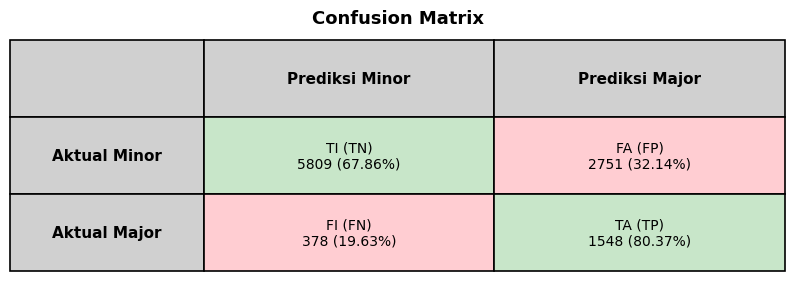

In [392]:
# confusion matrix
cm = confusion_matrix(y_test, y_pred)

TN = cm[0][0]  # Prediksi Minor, Aktual Minor (Benar)
FP = cm[0][1]  # Prediksi Major, Aktual Minor (Salah)
FN = cm[1][0]  # Prediksi Minor, Aktual Major (Salah)
TP = cm[1][1]  # Prediksi Major, Aktual Major (Benar)

total_minor_actual = TN + FP
total_major_actual = FN + TP

fig, ax = plt.subplots(figsize=(10, 3))
ax.axis('off')

table_data = [
    ['',              'Prediksi Minor',               'Prediksi Major'             ],
    ['Aktual Minor',  f'TI (TN)\n{TN} ({TN/total_minor_actual*100:.2f}%)', f'FA (FP)\n{FP} ({FP/total_minor_actual*100:.2f}%)'],
    ['Aktual Major',  f'FI (FN)\n{FN} ({FN/total_major_actual*100:.2f}%)', f'TA (TP)\n{TP} ({TP/total_major_actual*100:.2f}%)'],
]

table = ax.table(
    cellText=table_data,
    loc='center',
    cellLoc='center',
    bbox=[0, 0, 1, 1] 
)

table.auto_set_font_size(False)
table.set_fontsize(11)

col_widths = [0.25, 0.375, 0.375]
for (row, col), cell in table.get_celld().items():
    cell.set_width(col_widths[col])
    cell.set_height(0.33)
    cell.set_edgecolor('black')
    cell.set_linewidth(1.2)

    if row == 0 or col == 0:
        cell.set_facecolor('#D0D0D0')
        cell.set_text_props(fontweight='bold', fontsize=11)
    elif row == 1 and col == 1:
        cell.set_facecolor('#C8E6C9')
        cell.set_text_props(fontsize=10)
    elif row == 2 and col == 2:
        cell.set_facecolor('#C8E6C9')
        cell.set_text_props(fontsize=10)
    else:
        cell.set_facecolor('#FFCDD2')
        cell.set_text_props(fontsize=10)

ax.set_title('Confusion Matrix',
             fontsize=13, fontweight='bold', pad=12)
plt.show()

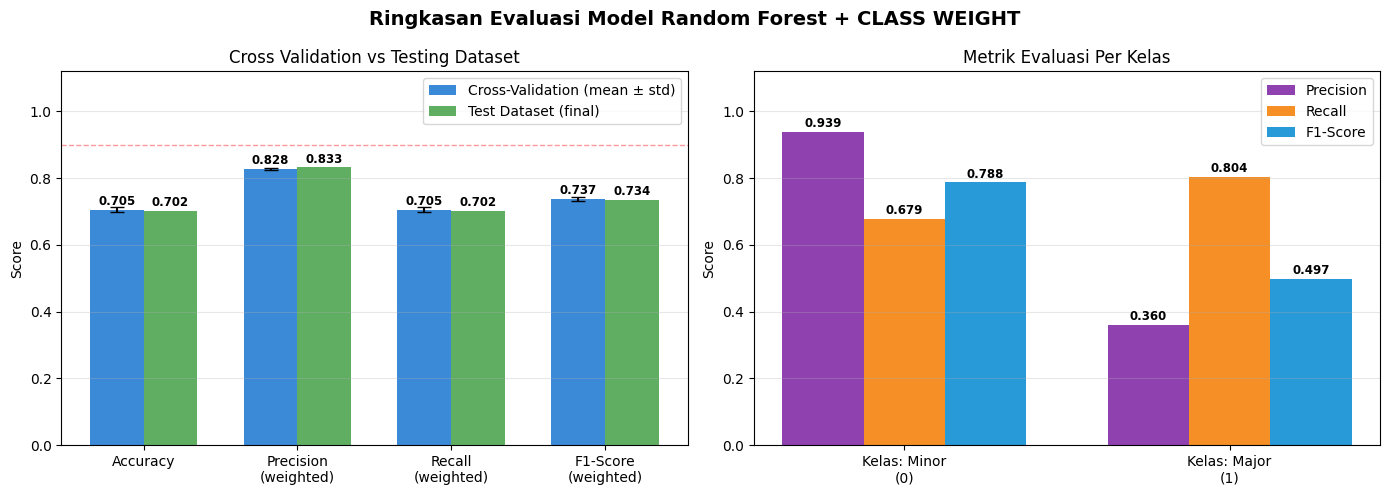

In [393]:
# EVALUASI PAKAI CV + TESTING
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Ringkasan Evaluasi Model Random Forest + CLASS WEIGHT', fontsize=14, fontweight='bold')

# panel kiri
ax1 = axes[0]
metrics_names  = ['Accuracy', 'Precision\n(weighted)', 'Recall\n(weighted)', 'F1-Score\n(weighted)']
cv_means  = [
    cv_results['test_accuracy'].mean(),
    cv_results['test_precision_weighted'].mean(),
    cv_results['test_recall_weighted'].mean(),
    cv_results['test_f1_weighted'].mean(),
]
cv_stds   = [
    cv_results['test_accuracy'].std(),
    cv_results['test_precision_weighted'].std(),
    cv_results['test_recall_weighted'].std(),
    cv_results['test_f1_weighted'].std(),
]
test_vals  = [acc, prec, rec, f1]

x      = np.arange(len(metrics_names))
width  = 0.35
colors_bar = ['#1976D2', '#43A047']

bars1 = ax1.bar(x - width/2, cv_means, width, yerr=cv_stds, capsize=5,
                label='Cross-Validation (mean ± std)', color=colors_bar[0], alpha=0.85)
bars2 = ax1.bar(x + width/2, test_vals, width,
                label='Test Dataset (final)', color=colors_bar[1], alpha=0.85)

for bar, val in zip(bars1, cv_means):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
             f'{val:.3f}', ha='center', va='bottom', fontsize=8.5, fontweight='bold')
for bar, val in zip(bars2, test_vals):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
             f'{val:.3f}', ha='center', va='bottom', fontsize=8.5, fontweight='bold')

ax1.set_ylim(0, 1.12)
ax1.set_xticks(x)
ax1.set_xticklabels(metrics_names)
ax1.set_ylabel('Score')
ax1.set_title('Cross Validation vs Testing Dataset')
ax1.legend()
ax1.axhline(y=0.9, color='red', linestyle='--', alpha=0.4, linewidth=1, label='Target ≥ 0.90')
ax1.grid(axis='y', alpha=0.3)

# panel kanan
ax2 = axes[1]
kelas      = ['minor', 'major']
prec_vals  = [prec_minor, prec_major]
rec_vals   = [rec_minor,  rec_major]
f1_vals    = [f1_minor,   f1_major]

x2    = np.arange(len(kelas))
w2    = 0.25
ax2.bar(x2 - w2, prec_vals, w2, label='Precision', color='#7B1FA2', alpha=0.85)
ax2.bar(x2,      rec_vals,  w2, label='Recall',    color='#F57C00', alpha=0.85)
ax2.bar(x2 + w2, f1_vals,   w2, label='F1-Score',  color='#0288D1', alpha=0.85)

for vals, offset in [(prec_vals, -w2), (rec_vals, 0), (f1_vals, w2)]:
    for i, v in enumerate(vals):
        ax2.text(i + offset, v + 0.005, f'{v:.3f}',
                 ha='center', va='bottom', fontsize=8.5, fontweight='bold')

ax2.set_ylim(0, 1.12)
ax2.set_xticks(x2)
ax2.set_xticklabels(['Kelas: Minor\n(0)', 'Kelas: Major\n(1)'])
ax2.set_ylabel('Score')
ax2.set_title('Metrik Evaluasi Per Kelas')
ax2.legend()
ax2.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

In [394]:
# feature importance
fi_df = pd.DataFrame({
    'Feature'   : FEATURE_COLS,
    'Importance': rf_final.feature_importances_
}).sort_values('Importance', ascending=False).reset_index(drop=True)

print("FEATURE IMPORTANCE")
print(f"{'-'*70}")
for i, row in fi_df.iterrows():
    bar = "█" * int(row['Importance'] * 60)
    print(f"{i+1:2}. {row['Feature']:<20} {row['Importance']:.4f}  {bar}")

FEATURE IMPORTANCE
----------------------------------------------------------------------
 1. scope_of_work        0.4422  ██████████████████████████
 2. city                 0.3724  ██████████████████████
 3. month                0.1854  ███████████


In [395]:
# KEY INSIGHTS
top1 = fi_df.iloc[0]

print("KEY INSIGHTS - MODEL RANDOM FOREST + CLASS WEIGHT")
print(f"{'-'*55}")
print(f"1) Fitur paling berpengaruh: '{top1['Feature']}'")
print(f"   (Importance: {top1['Importance']:.4f})")
print()
print(f"2) Akurasi model: {acc*100:.2f}%")
print(f"   (Cross-validation: {cv_results['test_accuracy'].mean()*100:.2f}% ± {cv_results['test_accuracy'].std()*100:.2f}%)")
print()
print(f"3) Class_weight = 'balanced' berhasil mengatasi imbalance {sev_counts['minor']/sev_counts['major']:.1f}:1")
print(f"   Precision major: {prec_major*100:.2f}% | Recall major: {rec_major*100:.2f}%")
print()
print(f"4) Threshold optimal: {best_threshold:.1f}")
print(f"   (Dipilih berdasarkan F1-Score tertinggi)")
print()
if acc >= 0.90:
    print(f"Status: SANGAT BAIK - Accuracy ≥ 90%")
elif acc >= 0.80:
    print(f"Status: BAIK - Accuracy ≥ 80%")
else:
    print(f"Status: Perlu ditingkatkan - Accuracy < 80%")
print(f"{'-'*55}")

KEY INSIGHTS - MODEL RANDOM FOREST + CLASS WEIGHT
-------------------------------------------------------
1) Fitur paling berpengaruh: 'scope_of_work'
   (Importance: 0.4422)

2) Akurasi model: 70.16%
   (Cross-validation: 70.50% ± 0.72%)

3) Class_weight = 'balanced' berhasil mengatasi imbalance 4.4:1
   Precision major: 36.01% | Recall major: 80.37%

4) Threshold optimal: 0.5
   (Dipilih berdasarkan F1-Score tertinggi)

Status: Perlu ditingkatkan - Accuracy < 80%
-------------------------------------------------------
